In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline

df = pd.read_csv('data/train.csv')

# Osnovne informacije o tipovima podataka i null vrednostima
print(df.info())
print(df.describe())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  str    
 2   region                54808 non-null  str    
 3   education             52399 non-null  str    
 4   gender                54808 non-null  str    
 5   recruitment_channel   54808 non-null  str    
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 5.4 MB
None
        employee_id  no_of_trainings           age  previous_year_rating  

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


kolone poput education i previous_year_rating često imaju nedostajuće vrednosti.

In [31]:
missing_values = df.isnull().sum()
print("Nedostajuće vrednosti:\n", missing_values[missing_values > 0])

# Popunjavanje: obrazovanje sa 'unknown' ili modom, a ocenu sa 0 ili medijanom
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['previous_year_rating'] = df['previous_year_rating'].fillna(0)

# Brisanje ID kolone jer ne utiče na model
df.drop('employee_id', axis=1, inplace=True)

Nedostajuće vrednosti:
 education               2409
previous_year_rating    4124
dtype: int64


skup je nebalansiran kao sto smo i primetili. To je ključno vizuelizovati odmah, jer će uticati na izbor metrike (Accuracy neće biti dovoljan, trebaće nam F1-score).

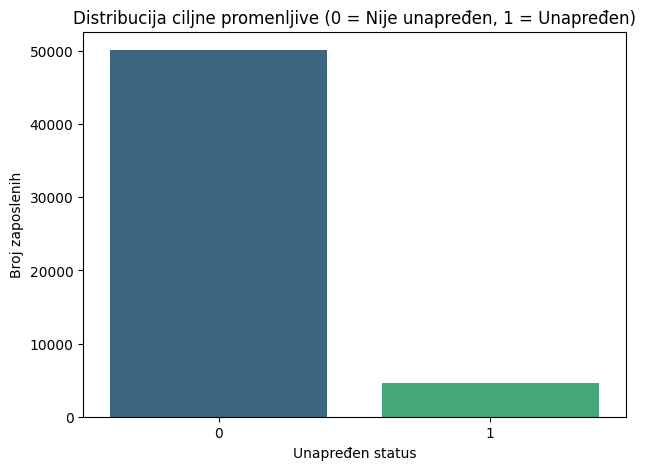

Procentualni udeo klasa:
is_promoted
0    91.482995
1     8.517005
Name: proportion, dtype: float64


In [32]:
# Ispravljen kod u skladu sa Seaborn v0.14.0 standardima
plt.figure(figsize=(7,5))
sns.countplot(x='is_promoted', data=df, hue='is_promoted', palette='viridis', legend=False)

plt.title('Distribucija ciljne promenljive (0 = Nije unapređen, 1 = Unapređen)')
plt.xlabel('Unapređen status')
plt.ylabel('Broj zaposlenih')
plt.show()

# Precizan procentualni prikaz nebalansiranosti
print("Procentualni udeo klasa:")
print(df['is_promoted'].value_counts(normalize=True) * 100)

Da bismo videli koji faktori (npr. nagrade, ocene, godine staža) najviše utiču na napredovanje, koristimo graf prikaz.

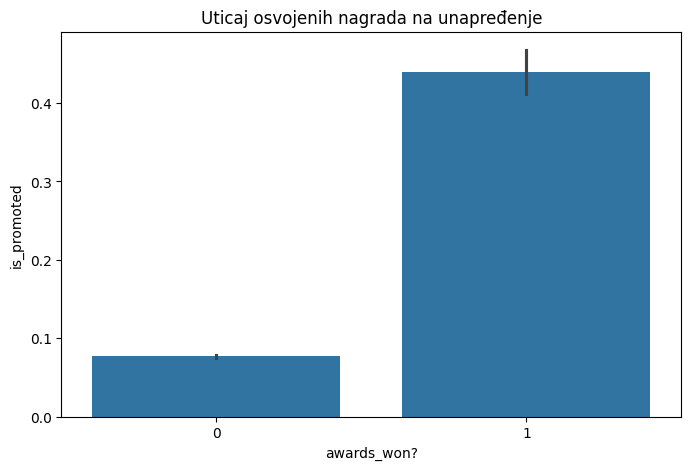

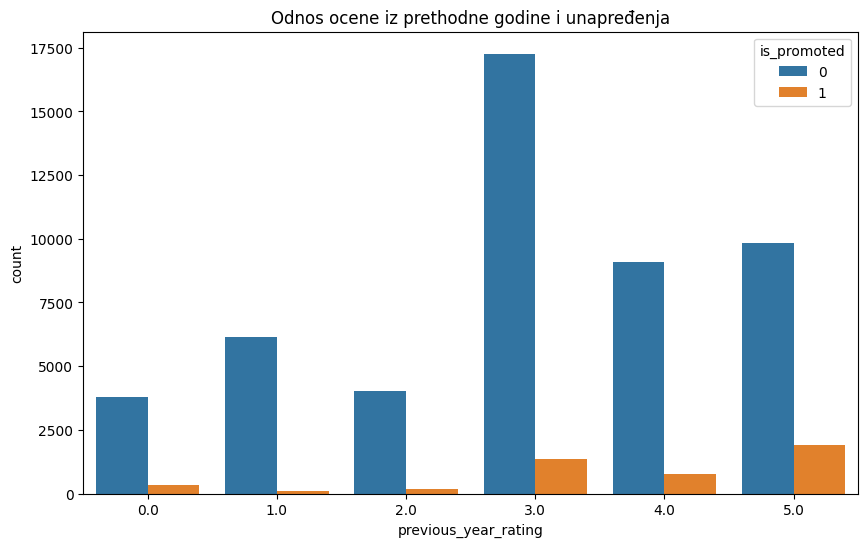

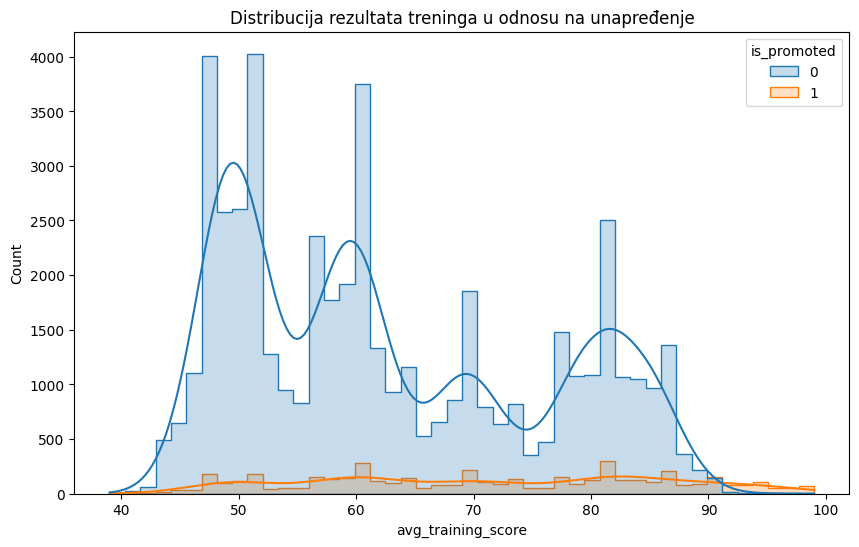

In [33]:
# Uticaj nagrada (awards_won?) na unapređenje
plt.figure(figsize=(8,5))
sns.barplot(x='awards_won?', y='is_promoted', data=df)
plt.title('Uticaj osvojenih nagrada na unapređenje')
plt.show()

# Uticaj ocene iz prethodne godine
plt.figure(figsize=(10,6))
sns.countplot(x='previous_year_rating', hue='is_promoted', data=df)
plt.title('Odnos ocene iz prethodne godine i unapređenja')
plt.show()

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='avg_training_score', hue='is_promoted', kde=True, element="step")
plt.title('Distribucija rezultata treninga u odnosu na unapređenje')
plt.show()

zaposleni koji su osvojili nagradu (vrednost 1) imaju drastično veće šanse za unapređenje (preko 40%) u odnosu na one bez nagrade (ispod 10%).

Najveći broj zaposlenih ima ocenu 3.0, ali je kod njih procenat unapređenja (narandzasti stubići) srazmerno mali u odnosu na ukupan broj.

Kod ocene 5.0, narandzasti stubic je najizrazeniji u odnosu na plavi, sto potvrdjuje da je previous_year_rating veliki faktor

sada cemo graficki prikazati uticaj demografskih faktora na sansu unapredjenja

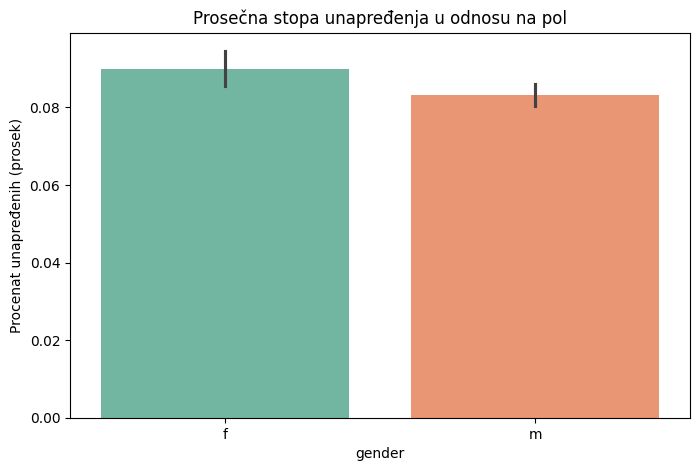

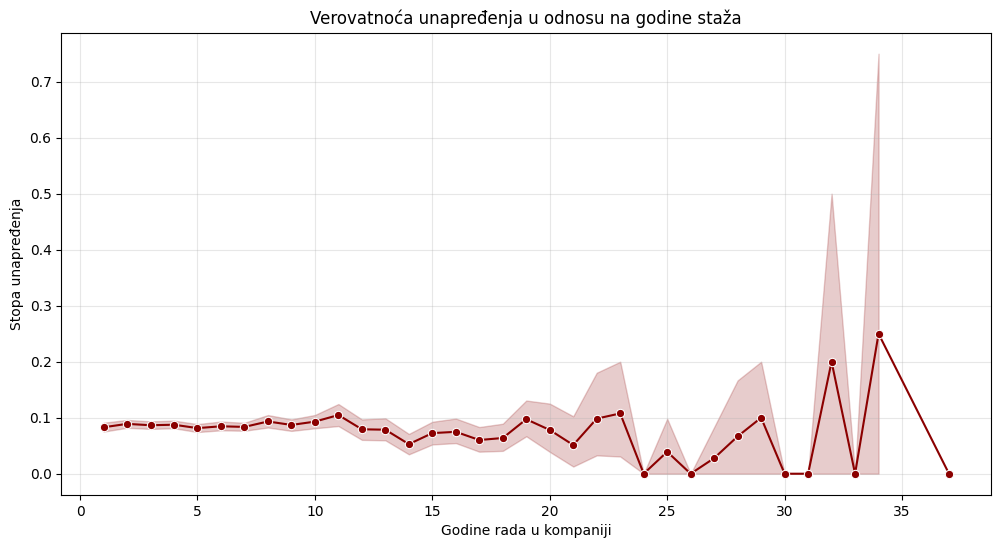

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='is_promoted', data=df, hue='gender', palette='Set2', legend=False)
plt.title('Prosečna stopa unapređenja u odnosu na pol')
plt.ylabel('Procenat unapređenih (prosek)')
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(x='length_of_service', y='is_promoted', data=df, color='darkred', marker='o')
plt.title('Verovatnoća unapređenja u odnosu na godine staža')
plt.xlabel('Godine rada u kompaniji')
plt.ylabel('Stopa unapređenja')
plt.grid(True, alpha=0.3)
plt.show()

stopa unapređenja kod žena (f) za nijansu veća nego kod muškaraca (m). Iako je razlika mala (oko 0.09 naspram 0.08), ovo je važan uvid jer sugeriše da pol nije prepreka za napredovanje u ovoj kompaniji.

Između 1 i 20 godina rada, stopa unapređenja je prilično stabilna i niska. Nakon 30 godina rada primećuju se veliki skokovi u sansi unapredjenja

Za kolone sa malo kategorija (kao što je gender) koristimo Label Encoding, a za one sa više (kao što su department ili region) koristimo One-Hot Encoding (tzv. "dummy" varijable).

In [35]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding za pol (M/F)
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

# One-Hot Encoding za ostale kategoričke kolone
# Ovo će kreirati nove kolone za svaki departman i region
df = pd.get_dummies(df, columns=['department', 'region', 'education'], drop_first=True)
df = pd.get_dummies(df, columns=['recruitment_channel'], drop_first=True)
print(f"Novi broj kolona nakon enkodiranja: {df.shape[1]}")

Novi broj kolona nakon enkodiranja: 53


Sada kada su nam svi podaci numerički, možemo generisati matricu korelacije da vidimo koji su atributi najuže povezani sa ciljnim atributom is_promoted.

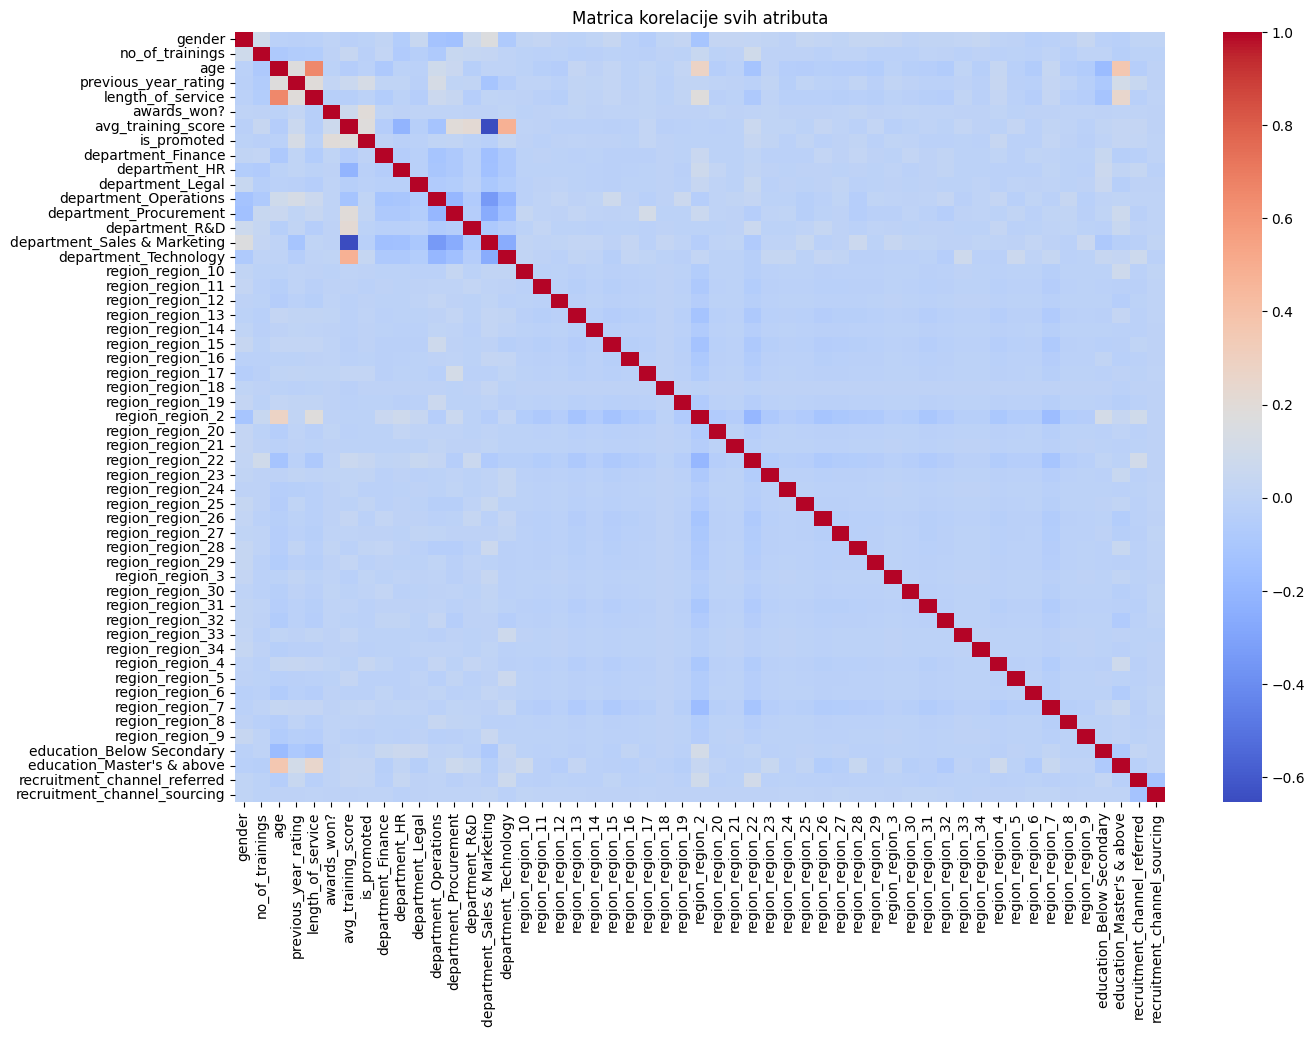

In [37]:
plt.figure(figsize=(15, 10))
# Dodaj numeric_only=True unutar corr() funkcije
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm') 
plt.title('Matrica korelacije svih atributa')
plt.show()

Matrica korelacije potvrđuje da demografski faktori (pol, region) imaju zanemarljiv uticaj na uspeh, dok su profesionalni rezultati poput avg_training_score i awards_won ključni faktori korelirani sa ciljnom promenljivom is_promoted. takodje previous year rating ima odredjeni uticaj na unapredjenje.

Pre nego što rešimo problem nebalansiranosti, moramo podeliti podatke kako ne bi došlo do "curenja" informacija iz test skupa u trening proces.

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop('is_promoted', axis=1)
y = df['is_promoted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

vrlo mali procenat ljudi je unapređen (obično oko 8-10%). Ako bismo sada pustili model, on bi naučio da samo "pogađa" da niko nije unapređen i imao bi visoku preciznost, ali bi bio beskoristan.

Koristićemo SMOTE (Synthetic Minority Over-sampling Technique) koji veštački kreira nove primere unapređenih zaposlenih na osnovu postojećih.

In [39]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Broj uzoraka pre SMOTE-a: {y_train.value_counts()}")
print(f"Broj uzoraka nakon SMOTE-a: {y_train_res.value_counts()}")

Broj uzoraka pre SMOTE-a: is_promoted
0    35097
1     3268
Name: count, dtype: int64
Broj uzoraka nakon SMOTE-a: is_promoted
0    35097
1    35097
Name: count, dtype: int64


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    predictions = model.predict(X_test)
    score = f1_score(y_test, predictions)
    results[name] = score
    print(f"{name} F1-Score: {score:.4f}")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression F1-Score: 0.4239
Random Forest F1-Score: 0.4064
Gradient Boosting F1-Score: 0.3887
XGBoost F1-Score: 0.4751


Ovi rezultati su odlični jer se savršeno uklapaju u pisani rad.

Prema literaturi, XGBoost je prepoznat kao model koji postiže najbolje rezultate, što je tvoj kod upravo i dokazao sa najvišim F1-Score-om od 0.4751.

Logistička regresija je postigla solidnih 0.4239, što potvrdjuje pretpostavku da je ona dobar polazni osnov za poređenje. Pošto je XGBoost pobednik, sada moramo primeniti Grid Search baš na njega kako bismo izvukli maksimum i završili taj deo obećane metodologije.

In [41]:
from sklearn.model_selection import GridSearchCV

# Definisanje parametara za XGBoost prema tvom planu (Grid Search)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

# Inicijalizacija Grid Search-a sa 5-fold kros-validacijom (Tačka 5)
grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
                        param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)

grid_xgb.fit(X_train_res, y_train_res)

print(f"Najbolji parametri za XGBoost: {grid_xgb.best_params_}")
print(f"Najbolji F1-Score nakon optimizacije: {grid_xgb.best_score_:.4f}")

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:00:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Najbolji parametri za XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Najbolji F1-Score nakon optimizacije: 0.9306


bravoooooo